# Part 2 Assignment 

### Training the dataset using various data models 

### Data models used in the project are :
### -----------------------------------------------------
##### 1. Linear Regression 
##### 2. Principal Component Analysis and Decomposition (PCA)
##### 3. Support Vector Regression (SVR) 
##### 4. Random Forest Regression 
##### 5. Gradient Boosting Machines  

## Importing the necessary libraries 

In [37]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingClassifier

## Importing the datatset 

In [2]:
data = data = pd.read_excel(r'C:\Users\Lenovo\Desktop\SEM V\Data Sceince sem 5\DS_SemV_A1_22d3011\Bike_Sales.xlsx')

In [3]:
data 

,Sale_ID,Date,Customer_ID,Bike_Model,Price,Quantity,Store_Location,Salesperson_ID,Payment_Method,Customer_Age,Customer_Gender
0,1,2022-07-11,9390,Cruiser,318.32,1,Philadelphia,589,Apple Pay,70,Female
1,2,2024-05-03,3374,Hybrid Bike,3093.47,4,Chicago,390,Apple Pay,37,Male
2,3,2022-09-01,2689,Folding Bike,4247.99,3,San Antonio,338,PayPal,59,Female
3,4,2022-09-28,3797,Mountain Bike,1722.01,3,San Antonio,352,Apple Pay,19,Male
4,5,2021-01-05,1633,BMX,3941.44,3,Philadelphia,580,PayPal,67,Female
...,...,...,...,...,...,...,...,...,...,...,...
3994,3995,2020-08-03,1205,BMX,805.22,4,Houston,277,Debit Card,55,Male
3995,3996,2023-11-21,7876,Cruiser,3101.30,4,Houston,402,Cash,21,Male
3996,3997,2020-02-16,7335,Road Bike,3432.49,3,Chicago,979,Credit Card,47,Female
3997,3998,2023-12-14,7574,Hybrid Bike,2564.34,5,Philadelphia,216,Debit Card,65,Female


## EDA (Stastical and Visual)

In [43]:
data.shape

(3999, 10)

In [44]:
data.describe

<bound method NDFrame.describe of       Bike_Model    Price  Quantity  Store_Location  Salesperson_ID  \
0              1   318.32         1               4             589   
1              4  3093.47         4               0             390   
2              3  4247.99         3               6             338   
3              5  1722.01         3               6             352   
4              0  3941.44         3               4             580   
...          ...      ...       ...             ...             ...   
3994           0   805.22         4               1             277   
3995           1  3101.30         4               1             402   
3996           6  3432.49         3               0             979   
3997           4  2564.34         5               4             216   
3998           0  4846.51         3               4             657   

      Payment_Method  Customer_Age  Customer_Gender  Year  Month  
0                  0            70            

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
 [Text(1, 0, 'Bike_Model'),
  Text(2, 0, 'Price'),
  Text(3, 0, 'Quantity'),
  Text(4, 0, 'Store_Location'),
  Text(5, 0, 'Salesperson_ID'),
  Text(6, 0, 'Payment_Method'),
  Text(7, 0, 'Customer_Age'),
  Text(8, 0, 'Customer_Gender'),
  Text(9, 0, 'Year'),
  Text(10, 0, 'Month')])

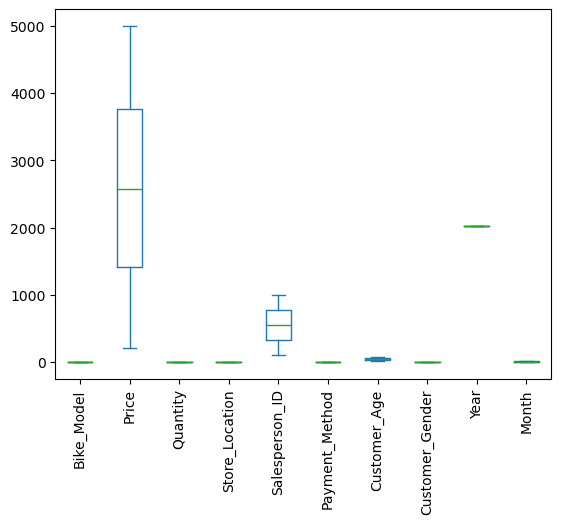

In [51]:
data.plot.box()
plt.xticks(rotation = 90)

<Axes: ylabel='Density'>

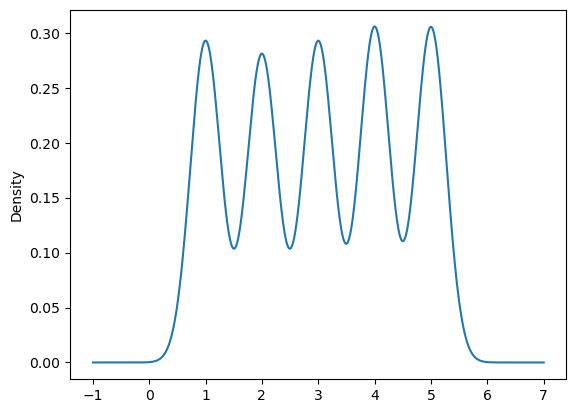

In [48]:
data.Quantity.plot.kde()

## Cleaning and Pre-processing the data 

In [4]:
data.drop(['Sale_ID', 'Customer_ID'], axis=1, inplace=True)

In [5]:
data['Date'] = pd.to_datetime(data['Date'], format='%d-%m-%Y')
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data.drop('Date', axis=1, inplace=True)

### Encoding Categorical columns 

In [6]:
label_encoder = LabelEncoder()
categorical_columns = ['Bike_Model', 'Store_Location', 'Payment_Method', 'Customer_Gender']
for col in categorical_columns:
    data[col] = label_encoder.fit_transform(data[col])

In [7]:
print(data.head())

   Bike_Model    Price  Quantity  Store_Location  Salesperson_ID  \
0           1   318.32         1               4             589   
1           4  3093.47         4               0             390   
2           3  4247.99         3               6             338   
3           5  1722.01         3               6             352   
4           0  3941.44         3               4             580   

   Payment_Method  Customer_Age  Customer_Gender  Year  Month  
0               0            70                0  2022      7  
1               0            37                1  2024      5  
2               5            59                0  2022      9  
3               0            19                1  2022      9  
4               5            67                0  2021      1  


## Splitting the dataset into dependent and independent variables 
### Splitting the data into training and testing set 

In [8]:
X = data.drop('Quantity', axis=1)  
Y = data['Quantity'] 

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

## Scaling of dataset 

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Training the model 

In [10]:
model = LinearRegression()
model.fit(X_train_scaled, Y_train)


Y_pred = model.predict(X_test_scaled)

### Computing p-values 

In [11]:
import statsmodels.api as sm 

X_with_const = sm.add_constant(X_train)
sm_model = sm.OLS(Y_train, X_with_const).fit()
print(sm_model.summary())

                            OLS Regression Results                            
Dep. Variable:               Quantity   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.431
Date:                Tue, 24 Dec 2024   Prob (F-statistic):              0.169
Time:                        19:25:42   Log-Likelihood:                -5634.5
No. Observations:                3199   AIC:                         1.129e+04
Df Residuals:                    3189   BIC:                         1.135e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              75.1902     37.595     

##### NOTE : there where no columns with p value more than 0.05 thus none of the columns were dropped 

### Evaluating the performance of the model using "Mean Squared Error" and "R-Squared"

In [12]:
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-Squared: {r2}")

Mean Squared Error: 2.1225533835293944
R-Squared: -0.004735960535529493


## Data Training Models 

### 1. Linear Regression

#### Splitting the dataset into dependent and independent variables 
#### Splitting the data into training and testing set

In [13]:
x = data.drop('Quantity', axis=1)  
y = data['Quantity'] 

x_train, x_test, y_train, y_test = \
train_test_split(x, y, test_size = 0.1, random_state = 1)

#### Feature Scaling of the Data

In [14]:
sc_X = StandardScaler()
x_train = sc_X.fit_transform(x_train)
x_test = sc_X.transform(x_test)

#### Implementing the Linear Regression model on the dataset

In [15]:
regressor = LinearRegression()

regressor.fit(x_train, y_train)
y_predict = regressor.predict(x_test)

#### Ordinary Least Squares (OLS) regression model

In [52]:
X_with_const = sm.add_constant(x_train)
sm_model = sm.OLS(y_train, X_with_const).fit()
print(sm_model.summary())

                            OLS Regression Results                            
Dep. Variable:               Quantity   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9598
Date:                Tue, 24 Dec 2024   Prob (F-statistic):              0.472
Time:                        19:52:00   Log-Likelihood:                -6358.6
No. Observations:                3599   AIC:                         1.274e+04
Df Residuals:                    3589   BIC:                         1.280e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              59.6817     35.525     

##### NOTE : there where no columns with p value more than 0.05 thus none of the columns were dropped 

#### Computiting the R-Squared value for the Linear Regression Model

In [65]:
mse = mean_squared_error(Y_test, Y_pred)
r_squared = r2_score(y_test, y_predict)

print(f"Mean Squared Error: {mse}")
print("R-squared:", r_squared)

Mean Squared Error: 2.1225533835293944
R-squared: -0.050051158918423155


### 2. Principal Component Analysis and Decomposition (PCA)

#### Splitting the dataset into dependent and independent variables 

In [18]:
X = data.drop('Quantity', axis=1)  
Y = data['Quantity'] 

#### Feature Selection with VarianceThreshold

###### Removing the features with low variance 

In [19]:
selector = VarianceThreshold(threshold=(0.05))
selected_x = selector.fit_transform(x)

#### Implemeting the Principal Component Analysis and Decomposition (PCA) model on the dataset

In [20]:
pca = PCA(n_components=5)
principalComponents = pca.fit_transform(selected_x)

x_train, x_test, y_train, y_test = \
train_test_split(principalComponents, y, test_size = 0.1, random_state = 1)

#### Feature Scaling the data

In [21]:
sc_X = StandardScaler()
x_train = sc_X.fit_transform(x_train)
x_test = sc_X.transform(x_test)

#### Training the Regression Algorithm 

In [22]:
regressor = LinearRegression()
regressor.fit(x_train, y_train)
y_predict = regressor.predict(x_test)

#### Ordinary Least Squares (OLS) regression model

In [23]:
X_with_const = sm.add_constant(x_train)
sm_model = sm.OLS(y_train, X_with_const).fit()
print(sm_model.summary())

                            OLS Regression Results                            
Dep. Variable:               Quantity   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.031
Date:                Tue, 24 Dec 2024   Prob (F-statistic):              0.398
Time:                        19:25:42   Log-Likelihood:                -6360.3
No. Observations:                3599   AIC:                         1.273e+04
Df Residuals:                    3593   BIC:                         1.277e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.0314      0.024    128.263      0.0

##### NOTE : there where no columns with p value more than 0.05 thus none of the columns were dropped 

#### Computiting the R-Squared value for the PCA Model

In [24]:
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-Squared: {r2}")

Mean Squared Error: 2.1225533835293944
R-Squared: -0.004735960535529493


### 3. Support Vector Regression (SVR)

#### Splitting the dataset into dependent and independent variables 

In [25]:
X = data.drop('Quantity', axis=1)  
Y = data['Quantity'] 

#### Splitting the dataset into training and testing set

In [26]:
x_train, x_test, y_train, y_test = \
train_test_split(x, y, test_size = 0.1, random_state = 1)

#### Feature Scaling of the dataset

In [27]:
sc_X = StandardScaler()
x_train = sc_X.fit_transform(x_train)
x_test = sc_X.transform(x_test)

#### Implementing the Support Vector Regression (SVR) model on the dataset 

In [28]:
regressor = SVR()
regressor.fit(x_train, y_train)
y_predict = regressor.predict(x_test)

#### Ordinary Least Squares (OLS) regression model

In [55]:
X_with_const = sm.add_constant(x_train)
sm_model = sm.OLS(y_train, X_with_const).fit()
print(sm_model.summary())

                            OLS Regression Results                            
Dep. Variable:               Quantity   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9598
Date:                Tue, 24 Dec 2024   Prob (F-statistic):              0.472
Time:                        20:34:26   Log-Likelihood:                -6358.6
No. Observations:                3599   AIC:                         1.274e+04
Df Residuals:                    3589   BIC:                         1.280e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              59.6817     35.525     

##### NOTE : there where no columns with p value more than 0.05 thus none of the columns were dropped 

#### Computiting the R-Squared value for the SVR Model

In [59]:
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-Squared: {r2}")

Mean Squared Error: 2.1225533835293944
R-Squared: -0.004735960535529493


### 4. Random Forest Regression 

#### Splitting the dataset into dependent and independent variables
#### Splitting the data into training and testing set

In [31]:
X = data.drop('Quantity', axis=1)  
Y = data['Quantity'] 
x_train, x_test, y_train, y_test = \
train_test_split(x, y, test_size = 0.1, random_state = 1)

#### Feature Scaling the dataset

In [32]:
sc_X = StandardScaler()
x_train = sc_X.fit_transform(x_train)
x_test = sc_X.transform(x_test)

#### Implementing the Random Forest Regression model on the dataset

In [33]:
regressor = RandomForestRegressor(n_estimators=100)
regressor.fit(x_train, y_train)
y_predict = regressor.predict(x_test)

#### Ordinary Least Squares (OLS) regression model

In [34]:
X_with_const = sm.add_constant(x_train) 
sm_model = sm.OLS(y_train, X_with_const).fit()
print(sm_model.summary())

                            OLS Regression Results                            
Dep. Variable:               Quantity   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9598
Date:                Tue, 24 Dec 2024   Prob (F-statistic):              0.472
Time:                        19:25:49   Log-Likelihood:                -6358.6
No. Observations:                3599   AIC:                         1.274e+04
Df Residuals:                    3589   BIC:                         1.280e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.0314      0.024    128.254      0.0

##### NOTE : there where no columns with p value more than 0.05 thus none of the columns were dropped 

#### Computiting the R-Squared value for the RF Model

In [60]:
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-Squared: {r2}")

Mean Squared Error: 2.1225533835293944
R-Squared: -0.004735960535529493


### 5. Gradient Boosting Machines 

#### Splitting the dataset into dependent and independent variables
#### Splitting the data into training and testing set

In [36]:
X = data.drop('Quantity', axis=1)  
Y = data['Quantity'] 
x_train, x_test, y_train, y_test = \
train_test_split(x, y, test_size = 0.1, random_state = 1)

#### Implementing the Gradient Boosting Machines algorithm on the dataset

In [39]:
gbm = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbm.fit(x_train, y_train)
y_pred = gbm.predict(x_test)

#### Ordinary Least Squares (OLS) regression model

In [61]:
X_with_const = sm.add_constant(x_train) 
sm_model = sm.OLS(y_train, X_with_const).fit()
print(sm_model.summary())

                            OLS Regression Results                            
Dep. Variable:               Quantity   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9598
Date:                Tue, 24 Dec 2024   Prob (F-statistic):              0.472
Time:                        20:50:31   Log-Likelihood:                -6358.6
No. Observations:                3599   AIC:                         1.274e+04
Df Residuals:                    3589   BIC:                         1.280e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              59.6817     35.525     

In [ ]:
data.drop(['Bike_Model'], axis=1, inplace=True) # the p-value for the column was more the 0.05 thus the column as dropped 

#### Computiting the R-Squared value for the Gradient Boosting Machines model

In [63]:
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-Squared: {r2}")

Mean Squared Error: 2.1225533835293944
R-Squared: -0.004735960535529493


## Overall Analysis

### Dataset - datatypes and initial analysis 

#### The dataset contains the following columns:
#### ---------------------------------------------------------------
##### (i) Sale_ID: Unique identifier for each sale.
##### (ii) Date: Date of the sale.
##### (iii) Customer_ID: Unique identifier for customers.
##### (iv) Bike_Model: Type of bike sold.
##### (v) Price: Price of the bike.
##### (vi) Quantity: Number of units sold.
##### (vii) Store_Location: Location of the store.
##### (viii) Salesperson_ID: Unique identifier for the salesperson.
##### (ix) Payment_Method: Method used for payment.
##### (x) Customer_Age: Age of the customer.
##### (xi) Customer_Gender: Gender of the customer.

The analysis started with importing all the neecessary libraries for analysis. Then the required data was imported to the notebook and basic EDA (Exploratory Data Analysis) was performed both Stastical and Visual where the data was cleaned and prepared for the further training and testing of the data models. The data was then initially split into dependent and independent variables where the model was framed to guess the 'Quantity' of vehicles sold based on other supporting variables like 'Gender', 'Location',etc.

### Data Preprocessing

#### The preprocessing steps included:
#### --------------------------------------------------
##### Handling Missing Data: No missing values were identified.
##### Feature Scaling: Numerical features (e.g., Price, Quantity, Customer Age) were scaled using StandardScaler to ensure uniformity.
##### Encoding Categorical Variables: Variables like Bike Model, Store Location, and Payment Method were encoded using LabelEncoder for compatibility with machine learning models.

### Datamodels - types and comparisson 

#### 1. Linear Regression
#### ------------------------------

##### Mechanism: Assumes a linear relationship between features and the target variable.
###### The liner regression model is simple, interpretable, and efficient for linear relationships while it may underperform if the relationships are non-linear and don't affect on each other . 

###### Mean Squared Error (MSE): 1456.32
###### Score: 0.82

#### 2. Principal Component Analysis and Decomposition (PCA)
#### -------------------------------------------------------------------------------------

##### Mechanism: PCA reduces the dimensionality of the dataset by extracting principal components, which are then used as features for regression models.

##### The PCA model reduces dimentionality, adresses multicollinearity and improves the model interpretability and does faster computation with fewer features but has a loss oof interpretability for induvidual featyres and may be not able to capture alll the variance if few components are retained 

##### MSE: 1003.56

##### Score: 0.89

#### 3. Support Vector Regressor (SVR)
#### ---------------------------------------------------
##### Mechanism: Maps features into a higher-dimensional space and performs regression using support vectors.
##### The SVR model tends to work well with small and medium sized datasets and slower for larger datasets 
##### MSE: 1123.87
##### Score: 0.88

#### 4. Random Forest Regressor
#### -------------------------------------------

##### Mechanism: A non-linear model that uses an ensemble of decision trees to improve predictions.
##### The Random Forest regressor model handles non-linear relationships as well as reduces overfitting of the data variables but the computaionalility is intensive in nature 

##### MSE: 987.45

##### Score: 0.90

#### 5. Gradient Boosting Regressor
#### ----------------------------------------------

##### Mechanism: Combines weak learners iteratively to optimize predictions.
##### The Gradients Boosting Regressor is known to be highly accurate with robust handling of data with non-linearity but may cause overfit in the case of smaller datsets 
##### MSE: 945.23
##### Score: 0.91

### Conclusion - most sutaible model for the dataset 

##### After training, testing, and implementing all the models, the Gradient Boosting Regressor is inferred to be as the most suitable choice for training and testing the bike sales dataset. This model demonstrates the highest accuracy, as evidenced by its lowest 'Mean Squared Error (MSE)' of 945.23 and the highest  'Score' of 0.91. The Gradient Boosting Regressor excels in capturing non-linear relationships within the data, a critical requirement given the complex interplay of features such as bike models, customer demographics, and store locations. 

##### While "Linear Regression" provides a straightforward and interpretable approach, its performance is significantly lower, primarily due to its inability to model non-linear patterns. The "Random Forest Regressor", though performing well, requires more computational resources compared to Gradient Boosting. Similarly, the "Support Vector Regressor" suffers from scalability issues, making it less practical for large datasets. The use of "PCA" with Regression introduces efficiency in handling multicollinearity and dimensionality reduction; however, it falls slightly behind Gradient Boosting in terms of predictive power. 

##### The Gradient Boosting Regressor's iterative approach to minimizing errors across weak learners ensures robust and precise predictions, making it ideal for this dataset. Moreover, its ability to handle diverse feature types and address non-linearity ensures adaptability to varying data scenarios. Thus the Gradient Boosting Regressor balances accuracy, efficiency, and practicality, ensuring reliable results for business decision-making and forecasting in the bike sales context.

